___
# <font color= #003366> **Visualizations for cat photos** </font>
- <Strong> Subject: </Strong>  <font color="blue">`Deep Learning` </font>
- <Strong> Project 2: </Strong>  <font color="blue">`GANs` </font>

<div style="display: flex; align-items: center;">
    <div style="flex: 1;">
        <img src="https://oci02.img.iteso.mx/Identidades-De-Instancia/ITESO/Logos%20ITESO/Logo-ITESO-Principal.jpg" width="300">
    </div>
</div>

___

In [11]:
import os
import numpy as np
import pandas as pd
from pathlib import Path
from torchvision import transforms
from torchvision.utils import make_grid
import torch
from PIL import Image
import matplotlib.pyplot as plt

In [3]:
# cargamos las imagenes de entrenamiento
image_dir = Path("../src/data/train")
images = list(image_dir.glob("*.jpg")) + list(image_dir.glob("*.png"))

In [4]:
print("total imgs:", len(images))

total imgs: 500


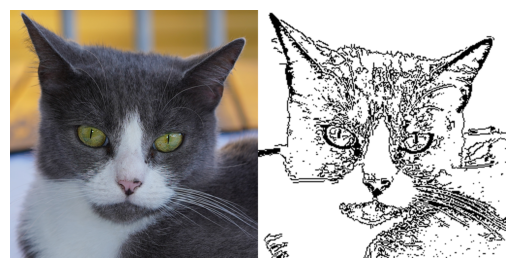

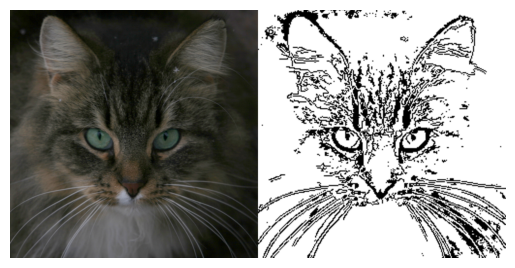

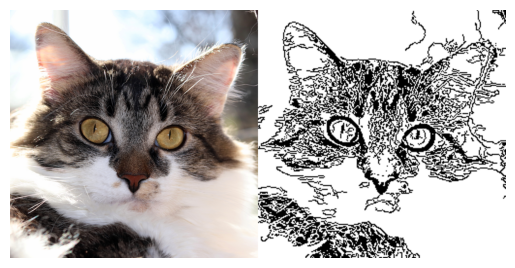

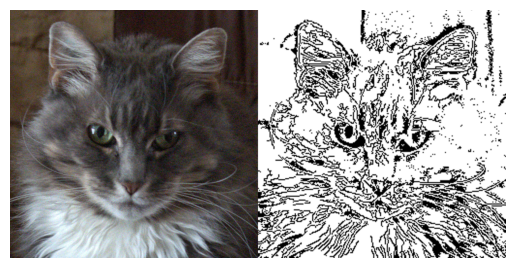

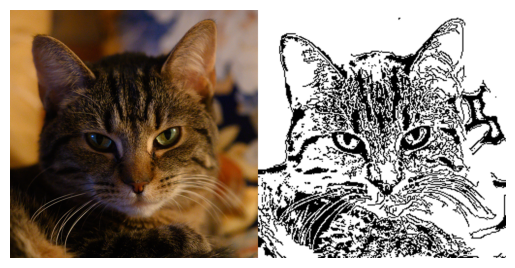

In [5]:
for img_path in images[:5]:
    img = Image.open(img_path).convert("RGB")
    plt.imshow(img)
    plt.axis("off")
    plt.show()

---
We can visualize 5 training images for our model

They are positioned this way because the models learns Side A (real) and Side B (sketch), so we opted to follow the same way and joined them.

Next steps are to check if our data is centered/aligned with each other, this is the easiest way for our model to comprehend the cat anatomy

---

## Centered Images Verification

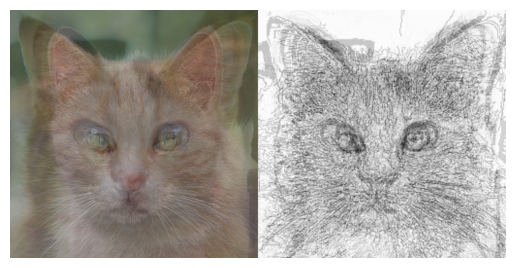

In [6]:
imgs = images[:500]

# cargar y convertir a RGB
loaded = [Image.open(p).convert("RGB") for p in imgs]

# redimensionar todas al tamaño de la primera
base_w, base_h = loaded[0].size
loaded = [img.resize((base_w, base_h)) for img in loaded]

# empezar con la primera
blend = loaded[0]

# ir mezclando con opacidad baja 
alpha = 0.2  

for img in loaded[1:]:
    blend = Image.blend(blend, img, alpha)

# mostrar resultado
plt.imshow(blend)
plt.axis("off")
plt.show()

---
Here we realize that our images are aligned.

Looking at the original image, it might be a little confusing, but when you analyze the sketch, it looks like a sketch of a single cat, perhaps a little distorted, but a cat nonetheless.

---

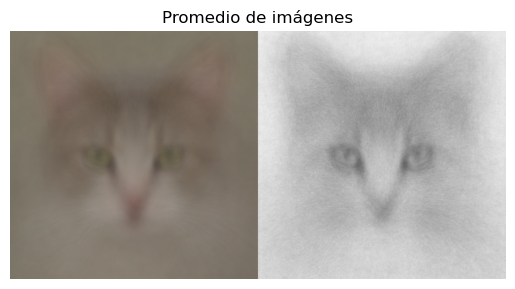

In [7]:
# tomar todas o las primeras n
imgs = [Image.open(p).convert("RGB") for p in images]

# redimensionar todas a la primera
w, h = imgs[0].size
imgs = [img.resize((w, h)) for img in imgs]

# apilar en numpy
arrs = np.stack([np.array(img, dtype=np.float32) for img in imgs])

# promedio
mean_img = arrs.mean(axis=0).astype(np.uint8)

# mostrar
plt.imshow(mean_img)
plt.axis("off")
plt.title("Promedio de imágenes")
plt.show()

---
Second method we use is to take the average; in this case, we see, although a little blurry, the face of a cat, which means that they are aligned and it will be a good dataset for our model to understand the data.

---

## Collage Many Images

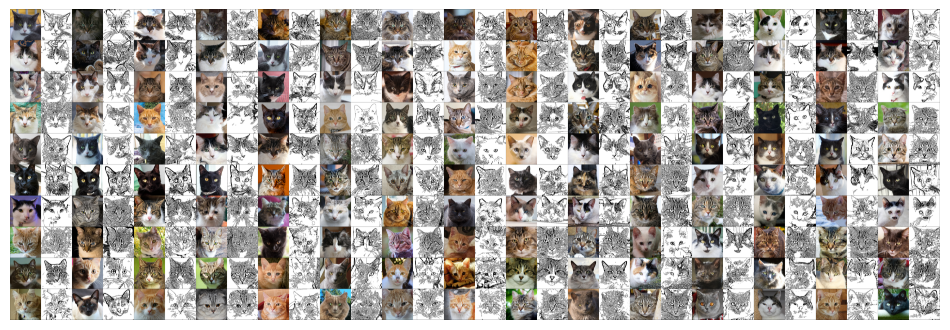

In [12]:
# cargar N imagenes (puedes subir a 200)
N = 150

# transform a tensor
to_tensor = transforms.ToTensor()

images = []
for img_path in list(image_dir.glob("*"))[:N]:
    img = Image.open(img_path).convert("RGB")
    images.append(to_tensor(img))

# stack
imgs = torch.stack(images)

# grid (10x15 por ejemplo)
grid = make_grid(imgs, nrow=15, padding=2)

plt.figure(figsize=(12, 12))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.show()

Since the GAN is meant to learn a mapping from side A (real) to side B (sketch), this mixed layout actually helps me confirm that both distributions are present and visually distinct. The real images have color, texture, and lighting variation, while the sketches are high-contrast and structurally consistent. That difference tells me the model has a strong signal to learn the translation between the two styles, and it reassures me that the GAN will have enough domain separation to understand “this is the photo side” and “this is the sketch side.”